이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- torchvision
- torchinfo
- numpy
- matplotlib

예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)

In [1]:

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()

다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.

In [2]:

import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 5-2 합성곱 신경망 모델 만들기

본 노트북은 본문 5-2절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 합성곱 계층(`nn.Conv2d`)과 풀링 계층(`nn.MaxPool2d`)의 사용법
- 합성곱 신경망에 맞춘 데이터 변환 객체
- 합성곱 신경망 숫자 분류기 모델을 정의하는 세 가지 방식
- 다층 퍼셉트론 모델과의 성능 비교

본문의 모델 5를 합성곱 신경망으로 다시 만든다.

## 합성곱 계층과 풀링 계층

- `nn.Conv2d` 클래스로 합성곱 계층을 만든다. 주요 인자는 다음과 같다.
    - `in_channels`: 입력 채널 수
    - `out_channels`: 출력 채널 수이며, 사용할 필터의 개수와 같다.
    - `kernel_size`: 필터의 크기
    - `stride`, `padding`: 필터를 옮기는 간격과 가장자리 처리 방식

In [3]:
######################################################################################
# 코드 5-3 - nn.Conv2d를 사용해 합성곱 계층 생성
######################################################################################

import torch.nn as nn

conv_layer = nn.Conv2d(
    in_channels=1,              # 입력 이미지의 채널 수 또는 특징 지도의 개수
    out_channels=16,            # 출력하는 특징 지도의 개수로, 필터의 수와 같다.
    kernel_size=3,              # 필터의 크기. 필터가 직사각형 모양이면 튜플로 지정
    stride=1,                   # 스트라이드 값으로 정수 또는 튜플로 지정(기본값 1)
    padding=0                   # 패딩 값으로 정수 또는 튜플로 지정(기본값 0)
)
# 위의 순서대로 인자를 지정하는 경우 인자 이름을 생략하고 위치 인자로 지정 가능
#     nn.Conv2d(1, 16, 3, 1, 0) 또는 nn.Conv2d(1, 16, 3) (stride와 padding 기본값 생략)

print(conv_layer)

Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))


- 합성곱 계층에 입력 텐서를 넣어 출력 형태를 확인한다.
    - 입력과 출력 모두 `(배치, 채널, 높이, 너비)` 형태의 4차원 텐서다.

In [4]:
######################################################################################
# 코드 5-4 - 합성곱 계층의 입력과 출력
######################################################################################

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch

# data_root: MNIST 데이터셋을 다운로드할 경로
data_root = '../../download'

# MNIST 테스트 데이터셋
test_set = datasets.MNIST(root=data_root, train=False, 
                          download=True, transform=transforms.ToTensor())

# 샘플 이미지 하나의 특징 지도 생성
img_sample = test_set[0][0]                         # (1, 28, 28) 형태의 샘플 텐서
feature_maps = conv_layer(img_sample.unsqueeze(0))  # -> (1, 16, 26, 26) 형태의 특징 지도 변환

# 크기 50인 배치 데이터
test_loader = DataLoader(test_set, batch_size=50)
for img_batch, _ in test_loader:                    # img_batch: (50, 1, 28, 28) 형태의 배치 텐서
    break
batch_feature_maps = conv_layer(img_batch)          # -> (50, 16, 26, 26) 형태의 특징 지도 변환

print(f'MNIST 샘플 입력시의 출력 형태: {tuple(feature_maps.shape)}')
print(f'MNIST 배치 입력시의 출력 형태: {tuple(batch_feature_maps.shape)}')

# in_channels와 채널 차원의 크기가 다르거나 채널 차원이 없으면 입력할 수 없음
#   img_without_channel = torch.rand((28, 28))
#   output_batch = conv_layer(img_without_channel)  # RuntimeError 예외

MNIST 샘플 입력시의 출력 형태: (1, 16, 26, 26)
MNIST 배치 입력시의 출력 형태: (50, 16, 26, 26)


- `nn.MaxPool2d` 클래스로 최대 풀링 계층을 만든다.
    - 학습할 파라미터가 없으므로 커널 크기와 스트라이드만 지정한다.

In [5]:
######################################################################################
# 코드 5-5 - 최대 풀링 계층 생성
######################################################################################

# 겹치지 않는 2x2 영역을 하나의 값으로 요약하는 최대 풀링
max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2)
# kernel_size 인자는 (세로, 가로) 튜플로도 지정할 수 있음
# stride 인자를 생략하면 kernel_size와 같은 값이 적용됨
# kernel_size, stride 순서대로 위치 인자로 지정할 수 있음
# nn.MaxPool2d(kernel_size=(2, 2)) 또는 nn.MaxPool2d(2, 2)와 같음

print(max_pool_layer)

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


In [6]:
######################################################################################
# 코드 5-6 - 최대 풀링 계층이 출력하는 텐서의 형태
######################################################################################

max_pooled = max_pool_layer(feature_maps)               # 샘플 하나의 특징 지도를 풀링
batch_max_pooled = max_pool_layer(batch_feature_maps)   # 배치 전체의 특징 지도를 풀링

print(f'26x26 특징 지도 풀링: {tuple(max_pooled.shape)}')
print(f'배치 특징 지도 풀링: {tuple(batch_max_pooled.shape)}')

26x26 특징 지도 풀링: (1, 16, 13, 13)
배치 특징 지도 풀링: (50, 16, 13, 13)


## 데이터 준비

- 합성곱 신경망은 이미지의 공간 구조를 그대로 사용하므로 평탄화하지 않는다.
    - 4-3절에서 사용한 데이터 변환 객체에서 평탄화 변환만 빼면 된다.

In [7]:
######################################################################################
# 코드 5-7 - 합성곱 신경망에 맞춰 수정한 데이터 변환 객체
######################################################################################

from torchvision import datasets, transforms

# 4장의 예제에서 평탄화(nn.Flatten) 변환을 제외한 데이터 변환 객체
transform_chain = transforms.Compose([
    transforms.ToTensor(),                  # 정규화된 텐서 변환
    transforms.Normalize((0.5,), (0.5,))    # 표준화
])

# 데이터셋 생성
train_set = datasets.MNIST(root=data_root, train=True, download=True, transform=transform_chain)
test_set = datasets.MNIST(root=data_root, train=False, download=True, transform=transform_chain)
print(f'변환된 이미지 텐서의 형태: {tuple(train_set[0][0].shape)}')

# 훈련, 검증 데이터셋 분리와 데이터로더 생성 과정은 4장의 예제와 동일

변환된 이미지 텐서의 형태: (1, 28, 28)


- 데이터셋을 훈련, 검증, 평가로 나누고 데이터로더를 만든다.

In [8]:
# 참고 - 데이터셋 분리 및 데이터로더 생성
from torch.utils.data import random_split, DataLoader

train_set, valid_set = random_split(
    train_set, [50000, 10000],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 128                                # 2의 거듭제곱수 추천
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 샘플 수: {len(train_set)}')
print(f'검증 샘플 수: {len(valid_set)}')
print(f'평가 샘플 수: {len(test_set)}')

훈련 샘플 수: 50000
검증 샘플 수: 10000
평가 샘플 수: 10000


## 모델 정의의 세 가지 방식

- 같은 구조의 합성곱 신경망을 세 가지 방식으로 정의해 비교한다.
    - 계층을 하나씩 나열하는 방식
    - 역할(특징 추출기와 분류기)에 따라 계층을 묶는 방식
    - 반복되는 합성곱 블록을 클래스로 만들어 재사용하는 방식
- 세 방식 모두 결과는 같으며, 모델이 커질수록 뒤쪽 방식이 관리하기 쉽다.

In [9]:
######################################################################################
# 코드 5-8 - 합성곱 신경망을 사용하는 숫자 분류기 모델 클래스
######################################################################################

# 합성곱 계층으로 만든 MNIST 숫자 분류기 클래스
class MNISTConvClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # 합성곱 계층 1: 1채널 이미지 입력받아 16장의 저수준 특징 지도를 출력
        #   필터 크기 3x3, 패딩 1, 스트라이드 1이므로 특징 지도 크기는 입력과 같음
        self.conv_layer_1 = nn.Conv2d(
            in_channels=1, 
            out_channels=16,
            kernel_size=3, 
            padding=1
        )
        # ReLU 활성화 계층
        self.activation_layer = nn.ReLU()
        # 최대 풀링 계층: 특징 지도의 2x2 영역을 최대값으로 요약
        #   요약 영역 크기(kernel_size)와 스트라이드가 같으면 stride 인자 생략 가능
        self.pooling_layer = nn.MaxPool2d(kernel_size=2)
        # 합성곱 계층 2: 16장의 저수준 특징 지도를 입력받아 32장의 고수준 특징 지도를 출력
        #   파라미터를 가진 계층으로 합성곱 계층 1과 구조가 같더라도 별도 객체로 생성
        self.conv_layer_2 = nn.Conv2d(
            in_channels=16, 
            out_channels=32,
            kernel_size=3, 
            padding=1
        )
        # ReLU 활성화 계층과 최대 풀링 계층은 함수형 계층으로 재사용 가능
        # 평탄화 계층: 32장의 2차원 특징 지도를 합쳐 1차원 텐서로 변환
        self.flatten_layer = nn.Flatten()
        # 선형 계층: 1차원 텐서를 입력받아 10개 클래스로 분류하는 완전 연결 계층
        self.output_layer = nn.Linear(32 * 7 * 7, 10)

    # 이하 번호는 본문에 정의된 8단계 각각에 대응
    def forward(self, x):               # 입력 x: (B, 1, 28, 28) (B: 배치 크기)
        x = self.conv_layer_1(x)        # ①   -> (B, 16, 28, 28)
        x = self.activation_layer(x)    # ②   -> (B, 16, 28, 28) (변화 없음)
        x = self.pooling_layer(x)       # ③   -> (B, 16, 14, 14)
        x = self.conv_layer_2(x)        # ④   -> (B, 32, 14, 14)
        x = self.activation_layer(x)    # ⑤   -> (B, 32, 14, 14) (변화 없음)
        x = self.pooling_layer(x)       # ⑥   -> (B, 32, 7, 7)
        x = self.flatten_layer(x)       # ⑦   -> (B, 1568) (32 * 7 * 7 = 1568)
        x = self.output_layer(x)        # ⑧   -> (B, 10)
        return x

model = MNISTConvClassifier()
print(model)

MNISTConvClassifier(
  (conv_layer_1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (activation_layer): ReLU()
  (pooling_layer): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_layer_2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten_layer): Flatten(start_dim=1, end_dim=-1)
  (output_layer): Linear(in_features=1568, out_features=10, bias=True)
)


In [10]:
######################################################################################
# 코드 5-9 - 역할에 따라 계층을 구분해 만든 합성곱 신경망 클래스
######################################################################################

class MNISTConvClassifier_v2(nn.Module):
    def __init__(self):
        super().__init__()
        # 특징 추출기: 두 합성곱 계층, 풀링 계층을 하나의 nn.Sequential 로 묶음
        self.features = nn.Sequential(
            # 위치 인자:  in_channels, out_channels, kernel_size, stride, padding 순서
            # 위치 인자로 padding 을 지정하려면 stride 인자의 기본값(1)도 지정해야 함
            nn.Conv2d(1, 16, 3, 1, 1),      # (B, 1, 28, 28) -> (B, 16, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2),                #                -> (B, 16, 14, 14)
            nn.Conv2d(16, 32, 3, 1, 1),     #                -> (B, 32, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2),                #                -> (B, 32,  7,  7)
        )
        # 분류기: 평탄화와 선형 계층을 하나의 nn.Sequential 로 묶음
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (B, 32, 7, 7) -> (B, 1568)
            nn.Linear(32 * 7 * 7, 10),      #               -> (B, 10)
        )

    # 데이터의 흐름이 역할에 따라 특징 추출기와 분류기 순서로 명확히 구분됨
    def forward(self, x):
        x = self.features(x)                # (B, 1, 28, 28) -> (B, 32, 7, 7)
        x = self.classifier(x)              # (B, 32, 7, 7) -> (B, 10)
        return x

model_v2 = MNISTConvClassifier_v2()
print(model_v2)

MNISTConvClassifier_v2(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=10, bias=True)
  )
)


In [11]:
######################################################################################
# 코드 5-10 - 합성곱 블록 ConvBlock 클래스를 재사용해 만든 합성곱 신경망 클래스
######################################################################################

from torchinfo import summary

# 합성곱 계층, ReLU 활성화 계층, 최대 풀링 계층을 묶어 정의한 합성곱 블록 클래스
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.conv_block(x)
# forward() 메서드 없이 nn.Sequential 의 파생 클래스로도 정의 가능 ([코드 3-17] 참조)

# 합성곱 블록 클래스를 재사용하는 깊은 합성곱 신경망 클래스
class DeepConvClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # ConvBlock 클래스를 사용해 한 줄의 코드로 계층 3개를 배치
        self.features = nn.Sequential(
            ConvBlock(1, 16),           # (B, 1, 28, 28) -> (B, 16, 14, 14)
            ConvBlock(16, 32),          #                -> (B, 32, 7, 7)
            ConvBlock(32, 64),          #                -> (B, 64, 3, 3)
            ConvBlock(64, 128)          #                -> (B, 128, 1, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 1 * 1, 10)
        )

    def forward(self, x):
        x = self.features(x)            # (B, 1, 28, 28) -> (B, 128, 1, 1)
        x = self.classifier(x)          #                -> (B, 10)
        return x

deep_model = DeepConvClassifier()
summary(deep_model, input_size=(1, 1, 28, 28), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
DeepConvClassifier                       [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 1, 1]            --
│    └─ConvBlock: 2-1                    [1, 16, 14, 14]           --
│    │    └─Sequential: 3-1              [1, 16, 14, 14]           160
│    └─ConvBlock: 2-2                    [1, 32, 7, 7]             --
│    │    └─Sequential: 3-2              [1, 32, 7, 7]             4,640
│    └─ConvBlock: 2-3                    [1, 64, 3, 3]             --
│    │    └─Sequential: 3-3              [1, 64, 3, 3]             18,496
│    └─ConvBlock: 2-4                    [1, 128, 1, 1]            --
│    │    └─Sequential: 3-4              [1, 128, 1, 1]            73,856
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-5                      [1, 128]                  --
│    └─Linear: 2-6                       [1, 10]                   1,290


## 모델 학습과 평가

- 학습 함수와 검증 함수는 4-2절에서 만든 조기 종료 방식의 함수를 그대로 사용한다.

In [12]:
# 참고 - 학습 함수는 4-2절의 학습 함수(조기 종료 방식)를 그대로 사용
import copy

# 배치별 모델 파라미터를 최적화하는 학습 함수
def train_batch(model, X_train, Y_train, criterion, optimizer):    
    model.train()                                       # 학습 모드
    Y_train_pred = model(X_train)
    train_loss = criterion(Y_train_pred, Y_train)       # 훈련 손실 계산
    optimizer.zero_grad()
    train_loss.backward()                               # 훈련 손실로 역전파
    optimizer.step()
    return train_loss.item()

# 모델 성능을 검증하는 평가 함수
def validate(model, X_valid, Y_valid, criterion):
    model.eval()                                        # 평가 모드
    with torch.no_grad():
        Y_valid_pred = model(X_valid)
        valid_loss = criterion(Y_valid_pred, Y_valid)   # 검증 손실 계산
    return valid_loss.item()

# 조기 종료를 적용한 학습 루프 함수
def train_with_early_stopping(model,
                              train_loader, valid_loader,
                              criterion, optimizer, epochs, patience):
    # 표준 학습 로거 생성
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.4f}', '{:.4f}'), target_rows=epochs)
    # 조기 종료를 위한 변수 초기화
    best_valid_loss = float('inf')  # 지금까지의 최소 검증 손실: 충분히 큰 값으로 초기화
    best_model_params = None        # 검증 손실이 최소일 때의 파라미터를 저장할 딕셔너리
    patience_counter = 0            # 참을성 카운터
    best_epoch = 0                  # 최적 에포크: 검증 손실이 최소일 때의 에포크

    for epoch in range(1, epochs + 1):
        # 훈련, 검증 손실의 가중합과 훈련, 검증 샘플 수 누적 변수: 에포크마다 초기화
        train_loss_sum, valid_loss_sum = 0, 0
        train_sample_size, valid_sample_size = 0, 0

        # 최적화 단계: train_batch()는 train_epoch()와 같지만 최적화 단위가 배치로 바뀜
        # 미니배치를 반복해 1 에포크 구성
        for X_train, Y_train in train_loader:
            # X_train, Y_train: 미니배치를 구성하는 입력과 정답 텐서
            train_loss = train_batch(model, X_train, Y_train, criterion, optimizer)
            # 각 배치별 가중 평균으로 손실값 계산 (미니배치마다 샘플의 수가 다를 수 있음)
            minibatch_size = X_train.size(0)                   # 미니배치의 샘플 수
            train_sample_size += minibatch_size                # 전체 샘플 수 누적 계산
            train_loss_sum += train_loss * minibatch_size      # 가중합
        train_loss_avg = train_loss_sum / train_sample_size    # 가중 평균

        # 검증 단계: validate()도 검증 단위가 배치로 바뀌며, 가중 평균으로 검증 손실 계산
        for X_valid, Y_valid in valid_loader:
            valid_loss = validate(model, X_valid, Y_valid, criterion)
            minibatch_size = X_valid.size(0)
            valid_sample_size += minibatch_size
            valid_loss_sum += valid_loss * minibatch_size
        valid_loss_avg = valid_loss_sum / valid_sample_size

        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss_avg, valid_loss_avg)

        # 조기 종료 판단
        if valid_loss_avg < best_valid_loss:
            # 최소 검증 손실보다 작은 경우 (현재가 최소 검증 손실)
            best_valid_loss = valid_loss_avg                        # 최소 검증 손실 갱신
            best_model_params = copy.deepcopy(model.state_dict())   # 최소 검증 손실 시점의 파라미터 저장
            best_epoch = epoch                                      # 최소 손실 에포크 갱신
            patience_counter = 0                                    # 참을성 카운터 초기화
        else:
            # 최소 검증 손실이 갱신되지 않은 경우
            patience_counter += 1                                   # 참을성 카운터 1 증가
            if patience_counter >= patience:                        # 한계 초과 시 조기 종료                
                break

    print(f'최적({best_epoch} 에포크/검증 손실 {best_valid_loss:.4f}) 파라미터로 모델 복원')
    model.load_state_dict(best_model_params)
    return log

In [13]:
# 참고 - 합성곱 신경망 구조의 숫자 분류기 모델 학습
import torch.optim as optim

# 합성곱 신경망을 사용한 숫자 분류기 모델 생성
model = MNISTConvClassifier()

# 하이퍼파라미터 설정: 4-3절의 다층 퍼셉트론 모델과 같은 값을 사용
LR = 0.001                                          # 학습률
EPOCHS = 20                                         # 전체 학습 에포크
PATIENCE = 5                                        # 참을성 한계

# 옵티마이저와 손실 함수
optimizer = optim.Adam(model.parameters(), lr=LR)   # Adam 옵티마이저
criterion = nn.CrossEntropyLoss()                   # 교차 엔트로피 손실 함수

# 모델 학습
log = train_with_early_stopping(
    model, train_loader, valid_loader, criterion, optimizer, EPOCHS, PATIENCE
)

에포크    훈련 손실    검증 손실     시간
  1/20       0.3324       0.1076     0:13


  2/20       0.0830       0.0696     0:26


  3/20       0.0592       0.0589     0:39


  4/20       0.0486       0.0589     0:53


  5/20       0.0410       0.0597     1:12


...

 10/20       0.0218       0.0516     2:48


 11/20       0.0200       0.0496     3:08


 12/20       0.0171       0.0509     3:27


 13/20       0.0149       0.0578     3:48


 14/20       0.0140       0.0588     4:07
최적(9 에포크/검증 손실 0.0476) 파라미터로 모델 복원


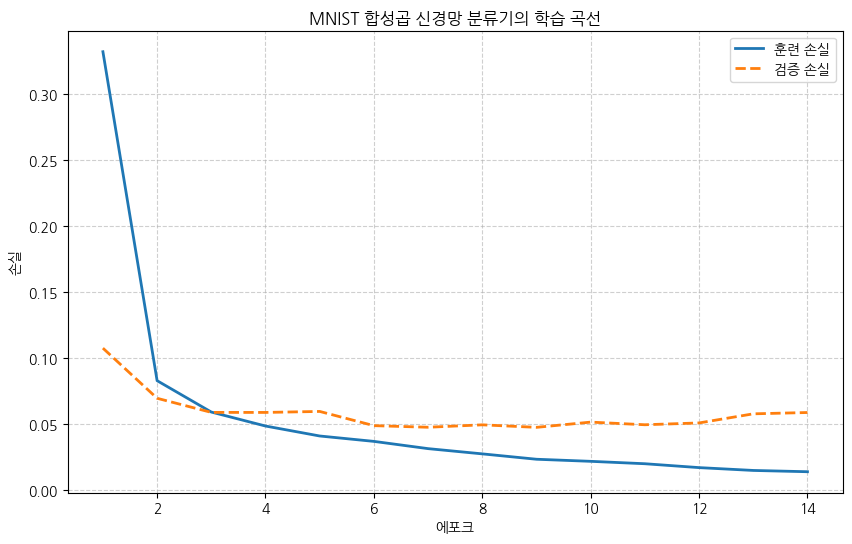

In [14]:
# 참고 - 학습 곡선 시각화
log.plot(title='MNIST 합성곱 신경망 분류기의 학습 곡선', y_label='손실')

- 훈련 데이터셋과 평가 데이터셋의 분류 정확도를 확인한다.
    - 다층 퍼셉트론 모델(4-3절)의 결과와 비교하면 개선 정도를 알 수 있다.

In [15]:
# 참고 - 훈련 데이터셋과 평가 데이터셋의 분류 정확도

# get_accuracy(): 공통 라이브러리의 분류 정확도 계산 함수
#   분류 정확도, 정답 개수, 전체 개수를 차례대로 반환
result_on_train = common.get_accuracy(model, train_loader)
result_on_test = common.get_accuracy(model, test_loader)

print(f'훈련 데이터셋 분류 정확도: {result_on_train[0]:.2f}%')
print(f'평가 데이터셋 분류 정확도: {result_on_test[0]:.2f}%')

훈련 데이터셋 분류 정확도: 99.52%
평가 데이터셋 분류 정확도: 98.73%


- 혼동 행렬로 분류 실패의 경향을 확인한다([그림 5-11]).

tensor([[ 977,    0,    0,    0,    0,    0,    1,    1,    1,    0],
        [   0, 1129,    2,    1,    1,    1,    1,    0,    0,    0],
        [   3,    1, 1012,    3,    3,    0,    0,    7,    3,    0],
        [   1,    0,    1, 1003,    0,    1,    0,    3,    1,    0],
        [   0,    0,    0,    0,  976,    0,    1,    0,    2,    3],
        [   2,    1,    0,    5,    0,  879,    2,    1,    1,    1],
        [   5,    2,    0,    0,    3,    6,  939,    0,    3,    0],
        [   0,    2,    4,    3,    1,    0,    0, 1015,    1,    2],
        [   5,    0,    2,    1,    2,    1,    0,    1,  960,    2],
        [   3,    1,    0,    2,   11,    3,    0,    5,    1,  983]])


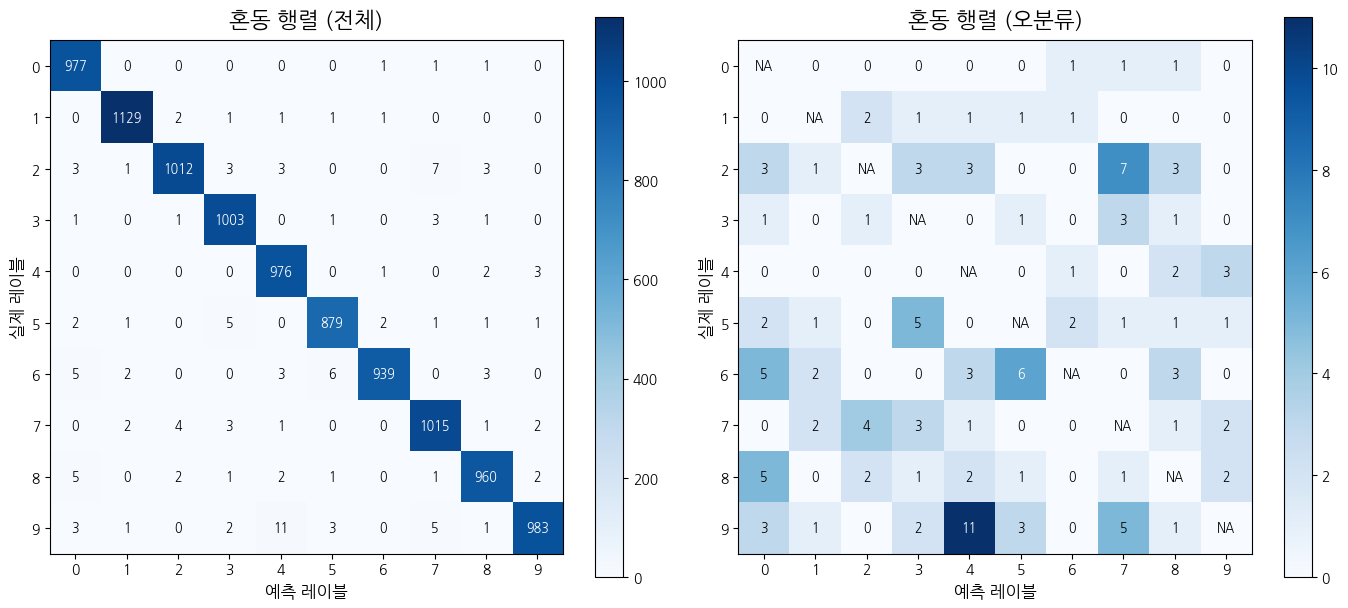

In [16]:
# 참고 - 혼동 행렬을 구하고 시각화([그림 5-11])
# get_confusion_matrix(): 공통 라이브러리의 혼동 행렬 계산 함수
cm = common.get_confusion_matrix(model, test_loader, num_classes=10)
print(cm)
# 시각화
viz.plot_confusion_matrix(cm, class_names=list('0123456789'))

## 다층 퍼셉트론의 한계를 넘었는가

- 정확도 개선만으로는 모델이 나아졌는지 판단하기 어렵다. 다층 퍼셉트론이 틀렸던 지점을 제대로 푸는지 확인해야 한다.
- 4-3절에서 다층 퍼셉트론이 7을 9로, 5를 3으로 잘못 분류했던 샘플을 합성곱 신경망으로 다시 분류해 본다([그림 5-12]).

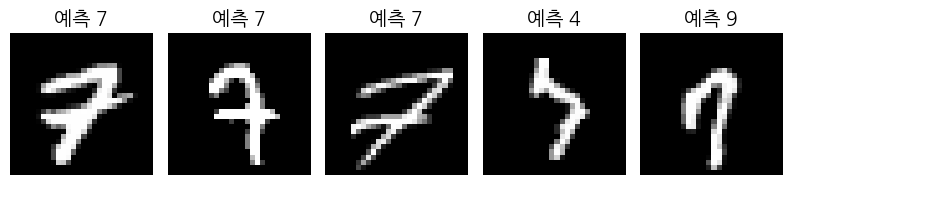

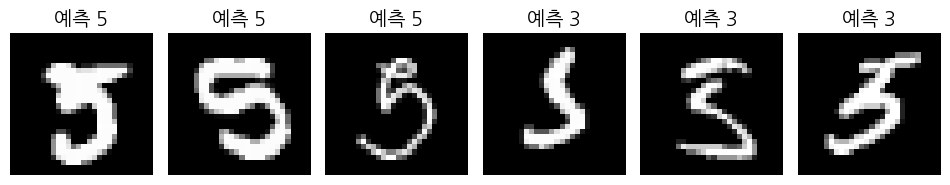

In [17]:
# 참고 - MLP 모델의 특정 오분류 패턴에 대한 합성곱 모델의 분류 결과([그림 5-12])
#   실습 환경에 따라 MLP 모델 및 합성곱 모델 분류 결과가 달라질 수 있으며
#   보여주는 사례는 저자의 테스트 환경 기준으로 뽑은 테스트 샘플에 해당함

# 특정 샘플 리스트의 분류 결과를 정답과 오답으로 나눠 출력하는 함수
def show_classification_results(idxs, labels, preds):
    correct_imgs, correct_descs = [], []
    wrong_imgs, wrong_descs = [], []

    for idx in idxs:
        img = test_set.data[idx]
        true_label = labels[idx].item()
        pred_label = preds[idx].item()
        desc = f'예측 {pred_label}'
        if true_label == pred_label:
            correct_imgs.append(img)
            correct_descs.append(desc)
        else:
            wrong_imgs.append(img)
            wrong_descs.append(desc)

    if correct_imgs:
        viz.plot_images(correct_imgs, correct_descs, images_per_row=3)
    if wrong_imgs:
        viz.plot_images(wrong_imgs, wrong_descs, images_per_row=3)

# 다층 퍼셉트론 모델이 7을 9로 잘못 분류한 샘플
misclassified_7_to_9_type1 = [1194, 3333, 1941]     # 합성곱 신경망이 정상 분류
misclassified_7_to_9_type2 = [726, 2070]      # 합성곱 신경망이 여전히 오분류
results_7 = [7, 7, 7, 4, 9]
idxs = misclassified_7_to_9_type1 + misclassified_7_to_9_type2
desc = [f'예측 {result}' for result in results_7]
imgs = [test_set.data[i] for i in idxs]
viz.plot_images(imgs, desc, images_per_row=6)


# 다층 퍼셉트론 모델이 5을 3로 잘못 분류한 샘플
misclassified_5_to_3_type1 = [412, 6042, 4271]      # 합성곱 신경망이 정상 분류  
misclassified_5_to_3_type2 = [340, 2597, 2035]      # 합성곱 신경망이 여전히 오분류
results_5 = [5, 5, 5, 3, 3, 3]
idxs = misclassified_5_to_3_type1 + misclassified_5_to_3_type2
desc = [f'예측 {result}' for result in results_5]
imgs = [test_set.data[i] for i in idxs]
viz.plot_images(imgs, desc, images_per_row=6)

- 다층 퍼셉트론은 숫자 0을 왼쪽으로 두 픽셀 옮기기만 해도 2로 잘못 분류했다.
    - 같은 샘플을 합성곱 신경망에 입력해 결과를 비교한다.

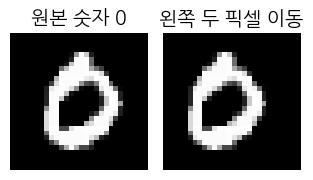

In [18]:
# 참고 - 왼쪽으로 두 픽셀 이동한 숫자 0 샘플 생성
# 평가 데이터셋의 첫 번째 0 샘플
for img, label in test_set:
    if label == 0:
        sample_0 = img
        break

# 왼쪽으로 두 픽셀 이동(오른쪽 두 열은 배경값 -1.0으로 채움)
sample_0_shifted = torch.full_like(sample_0, fill_value=-1.0)
sample_0_shifted[..., :-2] = sample_0[..., 2:]

# 원본 vs 이동본 비교 시각화
viz.plot_images(
    [sample_0, sample_0_shifted],
    ['원본 숫자 0', '왼쪽 두 픽셀 이동'],
    images_per_row=2,
)

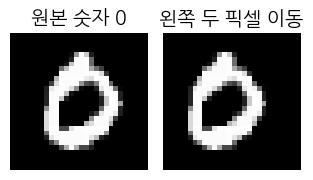

In [19]:
# 참고 - sample_0_shifted 텐서 생성 (본문 미공개 보조 코드)
# 평가 데이터셋에서 정답이 0 인 첫 번째 샘플을 찾는다
for img, label in test_set:
    if label == 0:
        sample_0 = img
        break

# 왼쪽으로 두 픽셀 이동 (오른쪽 두 열은 배경값 -1.0 으로 채움)
sample_0_shifted = torch.full_like(sample_0, fill_value=-1.0)
sample_0_shifted[..., :-2] = sample_0[..., 2:]

# 원본 vs 이동본 비교 시각화
viz.plot_images(
    [sample_0, sample_0_shifted],
    ['원본 숫자 0', '왼쪽 두 픽셀 이동'],
    images_per_row=2,
)

In [20]:
######################################################################################
# 코드 5-11 - 왼쪽으로 치우친 숫자 0에 대한 합성곱 신경망의 출력
######################################################################################

# sample_0_shifted: MNIST 숫자 0 을 왼쪽으로 두 픽셀 이동해 만든 숫자 0

model.eval()
with torch.no_grad():
    output = model(sample_0_shifted.unsqueeze(0))
    predicted = output.argmax(dim=1).item()

print(f'예측: {predicted}')                            # 출력값: 0
print(f'숫자 0 의 로짓: {output[0][0].item():.4f}')
print(f'숫자 2 의 로짓: {output[0][2].item():.4f}')

예측: 0
숫자 0 의 로짓: 12.4979
숫자 2 의 로짓: -5.2460


## 정리

- `nn.Conv2d`는 필터의 개수를 `out_channels`로 지정하며, 입력과 출력 모두 `(배치, 채널, 높이, 너비)` 형태의 4차원 텐서를 다룬다.
- `nn.MaxPool2d`는 학습 파라미터가 없어 커널 크기와 스트라이드만 지정한다.
- 합성곱 신경망은 이미지를 평탄화하지 않고 공간 구조를 그대로 사용한다.
- 모델 정의는 계층 나열, 역할별 묶음, 블록 재사용 순으로 관리하기 쉬워진다.
- 합성곱 신경망은 정확도가 높아졌을 뿐 아니라, 위치가 조금 달라진 숫자도 제대로 분류해 다층 퍼셉트론의 한계를 넘어선다.

> 학습 결과의 구체적인 수치는 실행 환경에 따라 본문과 조금씩 다를 수 있다.